In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error

# Bias Variance Trade-off
    The bias-variance tradeoff is a fundamental concept in machine learning that deals with the balance between two sources of error that prevent supervised learning algorithms from generalizing beyond their training set

- **Bias**

        The inablity of a mashine learning model to truly capter the relationship in the traning data.
  
- **Variances**

        Diffrence of fitts on difrent datasets
            For example
                Error in traning X_train data is 10
                &
                Error in predicting X_test dataset is 100
                (Then the variances is 90 - HEIGH VARIANCE)
  
- **Best model is when we get**

        {Low bias & Low Variance}

In [3]:
X = np.random.randn(100,1)
delta = 15*np.random.randn(100,1)

y = 7 + 15*X + 9*(X**2) + delta

In [4]:
X_train,X_test,y_train,y_test = train_test_split(X,y,train_size=.7)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((70, 1), (70, 1), (30, 1), (30, 1))

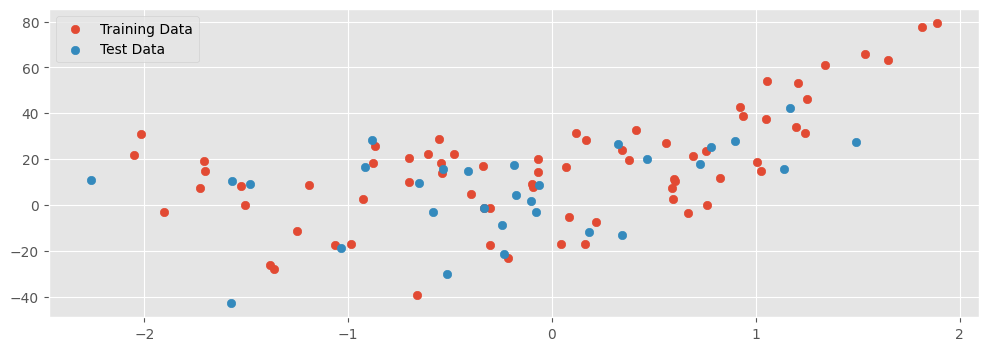

In [5]:
plt.figure(figsize=(12,4))

plt.scatter(X_train.ravel(), y_train.ravel(), label='Training Data')
plt.scatter(X_test.ravel(), y_test.ravel(), label='Test Data')

plt.legend()
plt.show()

In [6]:
lr = LinearRegression()
lr.fit(X_train,y_train)
No_D_pred = lr.predict(X_train)
No_D_pred_test = lr.predict(X_test)
No_D_bias = mean_squared_error(y_pred=No_D_pred, y_true=y_train)
No_D_varance = np.abs(No_D_bias - mean_squared_error(y_pred=No_D_pred_test, y_true=y_test))


poly_tran = PolynomialFeatures(degree=2)
X_train_2D_tran = poly_tran.fit_transform(X_train)
X_test_2D_tran = poly_tran.transform(X_test)
lr.fit(X_train_2D_tran,y_train)
y_2D_pred = lr.predict(X_train_2D_tran)
y_2D_pred_test = lr.predict(X_test_2D_tran)
y_2D_bias = mean_squared_error(y_pred=y_2D_pred, y_true=y_train)
y_2D_varance = np.abs(y_2D_bias - mean_squared_error(y_pred=y_2D_pred_test, y_true=y_test))


poly_tran = PolynomialFeatures(degree=20)
X_train_20D_tran = poly_tran.fit_transform(X_train)
X_test_20D_tran = poly_tran.transform(X_test)
lr.fit(X_train_20D_tran,y_train)
y_20D_pred = lr.predict(X_train_20D_tran)
y_20D_pred_test = lr.predict(X_test_20D_tran)
y_20D_bias = mean_squared_error(y_pred=y_20D_pred, y_true=y_train)
y_20D_varance = np.abs(y_20D_bias - mean_squared_error(y_pred=y_20D_pred_test, y_true=y_test))

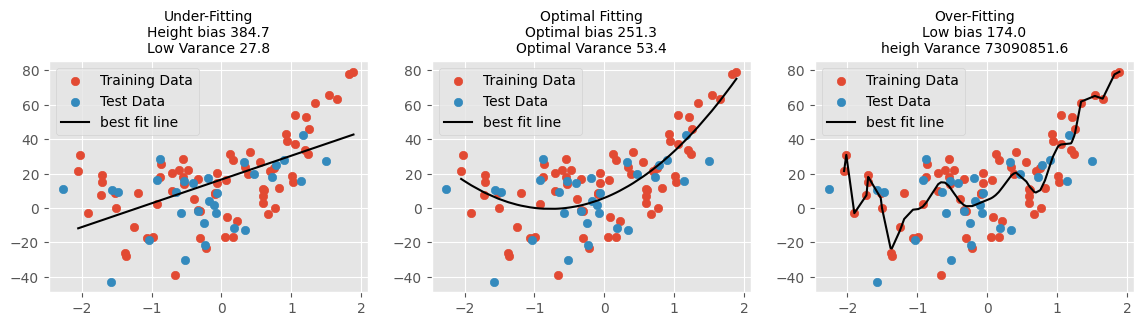

In [7]:
plt.figure(figsize=(14,3))

plt.subplot(131)
plt.scatter(X_train.ravel(), y_train.ravel(), label='Training Data')
plt.scatter(X_test.ravel(), y_test.ravel(), label='Test Data')
sns.lineplot(x=X_train.ravel(), y=No_D_pred.ravel(), color=(0,0,0,1), label='best fit line')
plt.title(f'Under-Fitting\nHeight bias {np.round(No_D_bias,1)}\nLow Varance {np.round(No_D_varance,1)}',fontsize=10)

plt.subplot(132)
plt.scatter(X_train.ravel(), y_train.ravel(), label='Training Data')
plt.scatter(X_test.ravel(), y_test.ravel(), label='Test Data')
sns.lineplot(x=X_train.ravel(), y=y_2D_pred.ravel(), color=(0,0,0,1), label='best fit line')
plt.title(f'Optimal Fitting\nOptimal bias {np.round(y_2D_bias,1)}\nOptimal Varance {np.round(y_2D_varance,1)}',fontsize=10)

plt.subplot(133)
plt.scatter(X_train.ravel(), y_train.ravel(), label='Training Data')
plt.scatter(X_test.ravel(), y_test.ravel(), label='Test Data')
sns.lineplot(x=X_train.ravel(), y=y_20D_pred.ravel(), color=(0,0,0,1), label='best fit line')
plt.title(f'Over-Fitting\nLow bias {np.round(y_20D_bias,1)}\nheigh Varance {np.round(y_20D_varance,1)}',fontsize=10)

plt.legend()
plt.show()